In [ ]:
import shutil
shutil.rmtree("../src/__pycache__", ignore_errors=True)

import sys
for mod in list(sys.modules.keys()):
    if 'geometry' in mod or 'reconstruction' in mod:
        del sys.modules[mod]

print("Cleared")

In [1]:
import sys
import os 
sys.path.append(os.path.abspath("../src"))
%load_ext autoreload
%autoreload 2
# from load_data import load_images, images_pil_to_cv, get_image_dimensions, load_image_pair
# from preprocess import resize_image, equalize_histogram, normalize_image, denoise_image, gamma_correction
# from feature_extraction import extract_sift_features, extract_orb_features, draw_keypoints, filter_features_by_response
# from feature_matching import match_features_flann, match_features_bf, draw_matches, extract_matched_points, filter_matches_by_distance
# from geometry import (
#     compute_essential_matrix,
#     recover_pose_from_essential,
#     create_projection_matrix,
#     triangulate_points,
#     filter_by_cheirality,
#     filter_by_depth
# )
from reconstruction import compute_intrinsic_matrix, reconstruct_two_view
from visualization import plot_3d_points, plot_2d_projections, plot_matches, plot_keypoints, plot_image_pair, save_ply


number of images loaded:  18
size of single image: (960, 1280)
TWO-VIEW RECONSTRUCTION PIPELINE

[1/10] Loading images...

[2/10] Creating intrinsic matrix...
  K = 
[[432.   0. 480.]
 [  0. 432. 640.]
 [  0.   0.   1.]]

[3/10] Extracting SIFT features...
Detected 3723 SIFT features
Detected 3719 SIFT features

[4/10] Matching features...
FLANN: Found 1152 good matches
FLANN: Found 1152 good matches

[5/10] Extracting matched points...

[6/10] Computing essential matrix...
Essential matrix computed (1072 inliers)

[7/10] Recovering camera pose...
Pose recovered (1057 points in front of both cameras)

[8/10] Creating projection matrices...

[9/10] Triangulating points...
Triangulated 1072 points

[10/10] Filtering points...
Depth filter: removed 0 outliers, kept 1072 points
✓ Saved 1072 points to week2_reconstruction.ply
Reconstruction complete: 1072 points

Final result: 1072 points


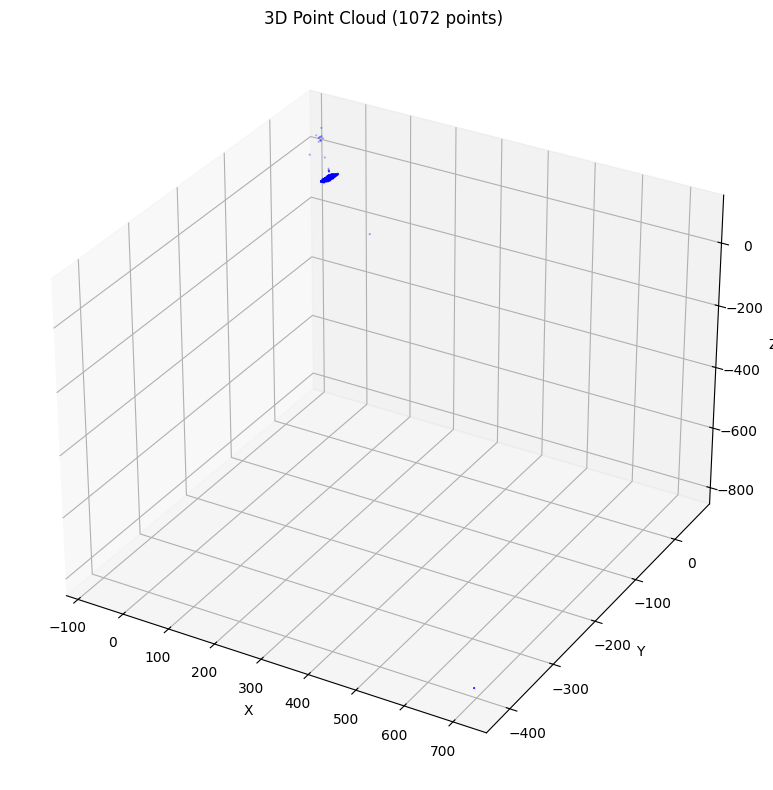

In [4]:
import os
from PIL import Image
path = r"C:\Users\altaf\OneDrive\Desktop\cv pics"
images = []
image_paths = []
count = 0
for filename in sorted(os.listdir(path)):
    if filename.endswith('.jpg'):
        count = count + 1
        img_path = os.path.join(path, filename)
        img = Image.open(img_path)
        images.append(img)
        image_paths.append(img_path)
print("number of images loaded: ", count)
print("size of single image:", images[0].size)
img_idx_1 = 0
img_idx_2 = 11
points_3d, R, t, K = reconstruct_two_view(
    image_paths[img_idx_1],
    image_paths[img_idx_2],
    output_ply='week2_reconstruction.ply'
)

print(f"\nFinal result: {len(points_3d)} points")
if len(points_3d) > 0:
    from visualization import plot_3d_points
    plot_3d_points(points_3d)


In [5]:
points_3d, R, t, K = reconstruct_two_view(image_paths[0], image_paths[11], output_ply=None)

print(f"K:\n{K}")
print(f"\nR:\n{R}")
print(f"t: {t.flatten()}")
print(f"\nPoint cloud bounds:")
print(f"X: {points_3d[:, 0].min():.1f} to {points_3d[:, 0].max():.1f}")
print(f"Y: {points_3d[:, 1].min():.1f} to {points_3d[:, 1].max():.1f}")
print(f"Z: {points_3d[:, 2].min():.1f} to {points_3d[:, 2].max():.1f}")
print(f"\nMean depth: {points_3d[:, 2].mean():.1f}")
print(f"Std dev: {points_3d[:, 2].std():.1f}")

TWO-VIEW RECONSTRUCTION PIPELINE

[1/10] Loading images...

[2/10] Creating intrinsic matrix...
  K = 
[[432.   0. 480.]
 [  0. 432. 640.]
 [  0.   0.   1.]]

[3/10] Extracting SIFT features...
Detected 3723 SIFT features
Detected 3719 SIFT features

[4/10] Matching features...
FLANN: Found 1149 good matches
FLANN: Found 1149 good matches

[5/10] Extracting matched points...

[6/10] Computing essential matrix...
Essential matrix computed (1067 inliers)

[7/10] Recovering camera pose...
Pose recovered (1049 points in front of both cameras)

[8/10] Creating projection matrices...

[9/10] Triangulating points...
Triangulated 1067 points

[10/10] Filtering points...
Depth filter: removed 1 outliers, kept 1066 points
Reconstruction complete: 1066 points
K:
[[432.   0. 480.]
 [  0. 432. 640.]
 [  0.   0.   1.]]

R:
[[ 0.99879385 -0.04610305 -0.01689236]
 [ 0.04630578  0.99885746  0.01181327]
 [ 0.01632843 -0.01258124  0.99978752]]
t: [ 0.75607726 -0.60596818  0.24728476]

Point cloud bounds:

In [ ]:
# Try different pairs
for i in range(0, 18, 2):
    print(" s")
    for j in range(i+5, 18):
        points_3d, R, t, K = reconstruct_two_view(
            image_paths[i],
            image_paths[j],
            output_ply=None
        )
        if len(points_3d) > 0:
            print(f"Images {i}-{j}: {len(points_3d)} points")